In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
%matplotlib widget

In [4]:
# Import and plot the raw spectra of the aspirin measurements
data_path = Path(r'.')
fig_path = Path(r'./figures')

files = [
    'nulla_backup_2026-06-04__18h34m55s',    
]

# Load all data
def load_xps(filepath):
    """Load a fixXPS-exported .txt file into a dict of arrays."""
    data = np.genfromtxt(filepath, names=True)
    return {name: data[name] for name in data.dtype.names}

spectra = []   # spectra[i] = {'file_name_1': dict, 'file_name_2': dict, ...}
for i in range(len(files)):
    spectra.append(load_xps(data_path / f'{files[i]}.txt'))

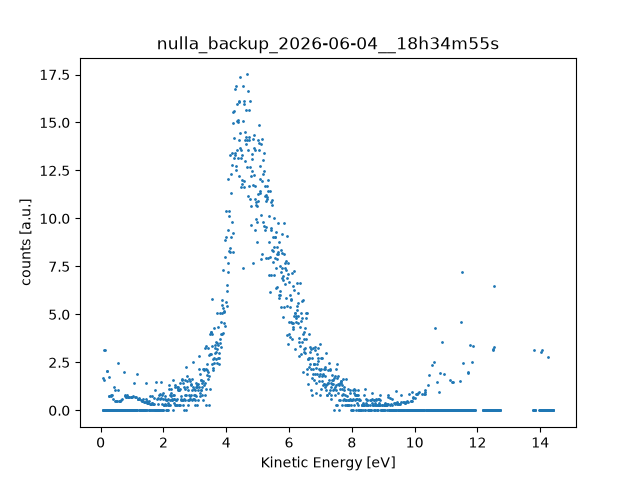

In [5]:
# Plot scatter of Kinetic Energy vs. counts for each imported file
fig_path.mkdir(parents=True, exist_ok=True)

for i in range(len(files)):
    s = spectra[i]
    fig, ax = plt.subplots()
    ax.scatter(s['KE_eV'], s['counts'], s=1)
    ax.set_xlabel('Kinetic Energy [eV]')
    ax.set_ylabel('counts [a.u.]')
    ax.set_title(files[i])
    fig.savefig(fig_path / f'{files[i]}.png', dpi=300, bbox_inches='tight')
    plt.show()